# 数据读取

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("D:\VsCodeProjects\Ecommerce_User_Analysis\data\cleaned_data.csv")

<>:5: SyntaxWarning: "\V" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\V"? A raw string is also an option.
<>:5: SyntaxWarning: "\V" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\V"? A raw string is also an option.
C:\Users\yivimc\AppData\Local\Temp\ipykernel_14192\1273339750.py:5: SyntaxWarning: "\V" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\V"? A raw string is also an option.
  df = pd.read_csv("D:\VsCodeProjects\Ecommerce_User_Analysis\data\cleaned_data.csv")


# 提取购买数据

In [2]:
buy_df = df[df["behavior_type"] == "buy"].copy()
buy_df.shape

(40461, 9)

In [3]:
buy_df.head()

,user_id,item_id,category_id,behavior_type,timestamp,datetime,date,hour,weekday
90,104083,738395,1158475,buy,1512053562,2017-11-30 22:52:42,2017-11-30,22,Thursday
131,1004381,5061759,2735466,buy,1512127405,2017-12-01 19:23:25,2017-12-01,19,Friday
134,1007595,3785181,1595193,buy,1511568471,2017-11-25 08:07:51,2017-11-25,8,Saturday
203,1008842,3938993,4672807,buy,1511923962,2017-11-29 10:52:42,2017-11-29,10,Wednesday
223,109474,89267,36289,buy,1512308015,2017-12-03 21:33:35,2017-12-03,21,Sunday


# 计算R值

In [ ]:
buy_df["datetime"] = pd.to_datetime(buy_df["datetime"])
snapshot_date = buy_df["datetime"].max()
print(snapshot_date)

2017-12-03 23:59:12


In [ ]:
rf = buy_df.groupby("user_id").agg({"datetime": "max"})
rf["Recency"] = (snapshot_date - rf["datetime"]).dt.days
rf.head()

,datetime,Recency
user_id,,
39,2017-12-02 23:02:15,1
62,2017-12-03 15:30:30,0
80,2017-11-29 20:15:35,4
150,2017-11-28 10:39:04,5
157,2017-12-02 14:29:28,1


# 计算F值

In [ ]:
frequency = buy_df.groupby("user_id").size()
rf["Frequency"] = frequency
rf.head()

,datetime,Recency,Frequency
user_id,,,
39,2017-12-02 23:02:15,1,1
62,2017-12-03 15:30:30,0,1
80,2017-11-29 20:15:35,4,1
150,2017-11-28 10:39:04,5,1
157,2017-12-02 14:29:28,1,1


# 用户评分

In [ ]:
rf["Frequency"].value_counts().head(20)  # 该份数据只覆盖一个月左右，很多值都是1

Frequency
1    37055
2     1539
3       90
4        8
5        4
6        1
Name: count, dtype: int64

In [ ]:
rf["Frequency"].describe()

count    38697.000000
mean         1.045585
std          0.226180
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          6.000000
Name: Frequency, dtype: float64

In [27]:
# rf["R_score"] = pd.qcut(rf["Recency"], 4, labels=[4, 3, 2, 1])和rf["F_score"] = pd.qcut(rf["Frequency"], 4, labels=[1, 2, 3, 4]),但是会出现报错，原因是Frequency的绝大部分值都是1,进行手动评分

In [15]:
rf["Recency"].value_counts().sort_index()

Recency
0    5172
1    5116
2    4128
3    4169
4    4331
5    4001
6    4290
7    3881
8    3609
Name: count, dtype: int64

In [16]:
def r_score(x):

    if x <= 1:
        return 4

    elif x <= 3:
        return 3

    elif x <= 5:
        return 2

    else:
        return 1


rf["R_score"] = rf["Recency"].apply(r_score)

In [ ]:
def f_score(x):

    if x >= 4:
        return 4

    elif x == 3:
        return 3

    elif x == 2:
        return 2

    else:
        return 1


rf["F_score"] = rf["Frequency"].apply(f_score)

In [ ]:
def segment(row):

    r = row["R_score"]
    f = row["F_score"]

    if r >= 3 and f >= 2:
        return "Core User"

    elif r >= 3 and f == 1:
        return "Active User"

    elif r <= 2 and f >= 2:
        return "At Risk User"

    else:
        return "Low Value User"


rf["Segment"] = rf.apply(segment, axis=1)

In [19]:
rf["Segment"].value_counts()

Segment
Low Value User    19530
Active User       17525
Core User          1060
At Risk User        582
Name: count, dtype: int64

In [20]:
rf["Segment"].value_counts(normalize=True) * 100

Segment
Low Value User    50.469029
Active User       45.287748
Core User          2.739230
At Risk User       1.503993
Name: proportion, dtype: float64

# 可视化

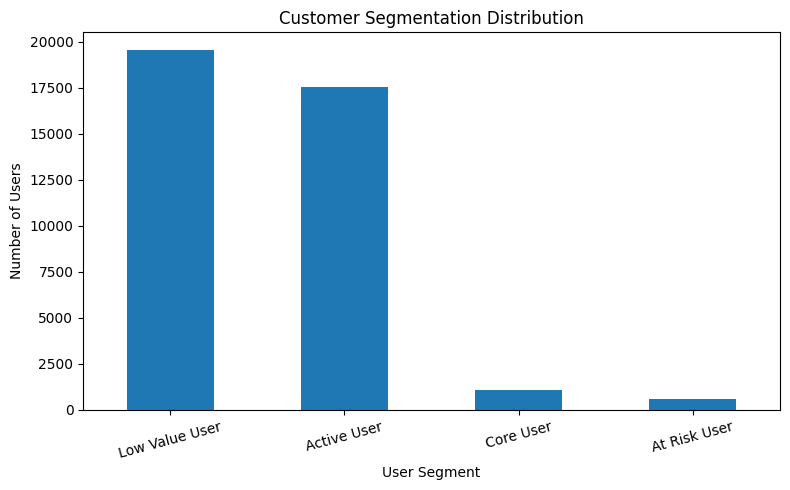

In [28]:
segment_count = rf["Segment"].value_counts()

plt.figure(figsize=(8, 5))

segment_count.plot(kind="bar")

plt.title("Customer Segmentation Distribution")

plt.xlabel("User Segment")

plt.ylabel("Number of Users")

plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    r"D:\VsCodeProjects\Ecommerce_User_Analysis\figures\Customer_Segmentation_Distribution.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

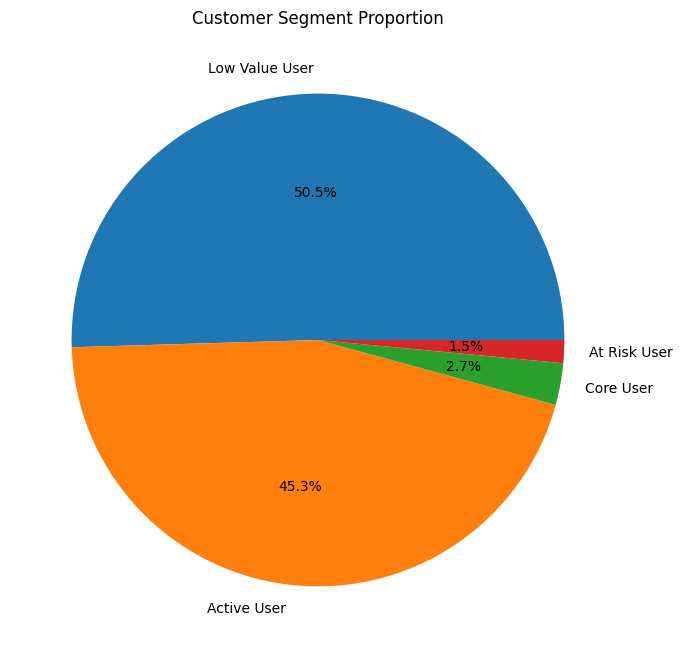

In [29]:
segment_ratio = rf["Segment"].value_counts(normalize=True) * 100

plt.figure(figsize=(8, 8))

plt.pie(segment_ratio, labels=segment_ratio.index, autopct="%1.1f%%")

plt.title("Customer Segment Proportion")

plt.savefig(
    r"D:\VsCodeProjects\Ecommerce_User_Analysis\figures\Customer_Segment_Proportion.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

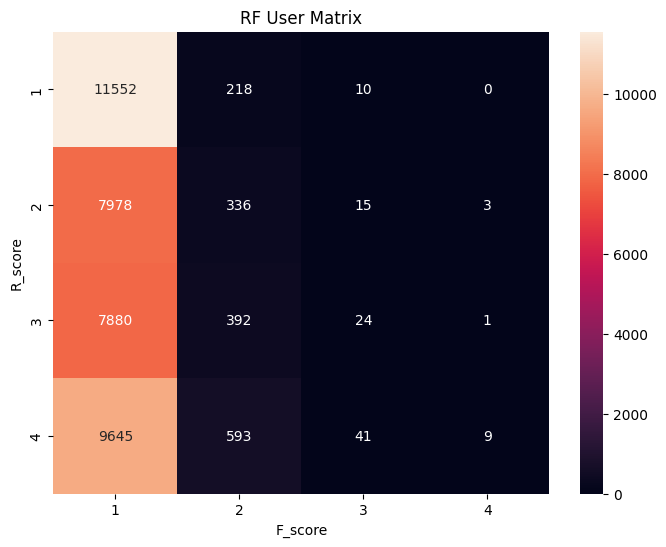

In [30]:
rf_matrix = pd.crosstab(rf["R_score"], rf["F_score"])


plt.figure(figsize=(8, 6))

sns.heatmap(rf_matrix, annot=True, fmt="d")

plt.title("RF User Matrix")

plt.savefig(
    r"D:\VsCodeProjects\Ecommerce_User_Analysis\figures\RF_User_Matrix.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()